# XOPT - CONNECTED COMPONENTS IN MAX-K-CUT

This notebook demonstrates that, for certain instance configurations, correcting the trajectory in the LTM is not sufficient to guarantee the desirable properties of the **max-k-cut** application. The high-quality solutions stored in distinct connected components may represent different ways of organizing the solution, indicating alternative structural patterns in the long-term memory.

### PROJECT SETUP

In [1]:
import sys
import copy
import warnings

import pandas            as pd
import networkx          as nx
import matplotlib.pyplot as plt

from math            import ceil
from pathlib         import Path
from IPython.display import display


warnings.filterwarnings('ignore', category=UserWarning)

In [2]:
if (Path.cwd() / 'lib').exists():
    EXPERIMENTS_DIR = Path.cwd()
else:
    EXPERIMENTS_DIR = next(
        candidate / 'notebooks/experiments_sbpo'
        for candidate in [Path.cwd(), *Path.cwd().parents]
        if (candidate / 'notebooks/experiments_sbpo/lib').exists()
    )


if str(EXPERIMENTS_DIR) not in sys.path:
    sys.path.insert(0, str(EXPERIMENTS_DIR))

In [3]:
from lib.paths  import find_project_root

from lib.graph  import build_top_ltm
from lib.ltm    import build_solution_swap_graph    , \
                       facilities_from_binary_vector, \
                       complete_long_term_memory_with_swap_trajectories

from lib.tsplib import TSPLIBInstanceSpec                  , \
                       assignment_profile                  , \
                       extract_geometric_structures        , \
                       refresh_result_from_long_term_memory, \
                       run_tsplib_instance_analysis        , \
                       solution_table_for_result           , \
                       structure_nodes_table_for_result    , \
                       structure_table_for_result
from lib.plots  import max_k_cut_color_by_selected_facility, \
                       plot_max_k_cut_clusters             , \
                       plot_solution_map


PROJECT_ROOT = find_project_root()

print(f'Project root is {PROJECT_ROOT}')

Project root is /home/rei-luisinho/xopt


### EXPERIMENT CONFIGURATION

In [4]:
TOP_FRACTION = 0.05

SOLVER_PARAMS = {
    'restarts'       : 10,
    'max_iter'       : 30,
    'swap_samples'   : 64,
    'seed'           : 42,
    'details_format' : 'binary',
}

MAX_K_CUT_RESTARTS = 40
MAX_K_CUT_MAX_ITER = 2000
GLOBAL_SEED        = 42

SHOW_BASEMAPS = False

INSTANCE_GROUPS = {
    'WORKS': [
        {'name' : 'kroB200', 'dimension' : 200, 'edge_weight_type' : 'EUC_2D', 'p' : 5, 'url' : 'https://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/kroB200.tsp.gz', 'raw_path' : 'notebooks/experiments_sbpo/artifacts/tsplib_tsp/kroB200.tsp'},
        {'name' : 'lin105' , 'dimension' : 105, 'edge_weight_type' : 'EUC_2D', 'p' : 5, 'url' : 'https://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/lin105.tsp.gz' , 'raw_path' : 'notebooks/experiments_sbpo/artifacts/tsplib_tsp/lin105.tsp' },
        {'name' : 'rd100'  , 'dimension' : 100, 'edge_weight_type' : 'EUC_2D', 'p' : 5, 'url' : 'https://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/rd100.tsp.gz'  , 'raw_path' : 'notebooks/experiments_sbpo/artifacts/tsplib_tsp/rd100.tsp'  },
        {'name' : 'u574'   , 'dimension' : 574, 'edge_weight_type' : 'EUC_2D', 'p' : 5, 'url' : 'https://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/u574.tsp.gz'   , 'raw_path' : 'notebooks/experiments_sbpo/artifacts/tsplib_tsp/u574.tsp'   },
    ],
    'NOT WORKS': [
        {'name' : 'pr136'  , 'dimension' : 136, 'edge_weight_type' : 'EUC_2D', 'p' : 5, 'url' : 'https://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/pr136.tsp.gz'  , 'raw_path' : 'notebooks/experiments_sbpo/artifacts/tsplib_tsp/pr136.tsp'  },
        {'name' : 'rat195' , 'dimension' : 195, 'edge_weight_type' : 'EUC_2D', 'p' : 5, 'url' : 'https://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/rat195.tsp.gz' , 'raw_path' : 'notebooks/experiments_sbpo/artifacts/tsplib_tsp/rat195.tsp' },
        {'name' : 'bier127', 'dimension' : 127, 'edge_weight_type' : 'EUC_2D', 'p' : 5, 'url' : 'https://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/bier127.tsp.gz', 'raw_path' : 'notebooks/experiments_sbpo/artifacts/tsplib_tsp/bier127.tsp'},
        {'name' : 'pr226'  , 'dimension' : 226, 'edge_weight_type' : 'EUC_2D', 'p' : 5, 'url' : 'https://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/pr226.tsp.gz'  , 'raw_path' : 'notebooks/experiments_sbpo/artifacts/tsplib_tsp/pr226.tsp'  },
    ],
    'NOT NECESSARY': [
        {'name' : 'a280'  , 'dimension' : 280, 'edge_weight_type' : 'EUC_2D', 'p' : 5, 'url' : 'https://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/a280.tsp.gz'  , 'raw_path' : 'notebooks/experiments_sbpo/artifacts/tsplib_tsp/a280.tsp'  },
        {'name' : 'ali535', 'dimension' : 535, 'edge_weight_type' : 'GEO'   , 'p' : 5, 'url' : 'https://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/ali535.tsp.gz', 'raw_path' : 'notebooks/experiments_sbpo/artifacts/tsplib_tsp/ali535.tsp'},
        {'name' : 'att48' , 'dimension' : 48 , 'edge_weight_type' : 'ATT'   , 'p' : 5, 'url' : 'https://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/att48.tsp.gz' , 'raw_path' : 'notebooks/experiments_sbpo/artifacts/tsplib_tsp/att48.tsp' },
        {'name' : 'att532', 'dimension' : 532, 'edge_weight_type' : 'ATT'   , 'p' : 5, 'url' : 'https://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/att532.tsp.gz', 'raw_path' : 'notebooks/experiments_sbpo/artifacts/tsplib_tsp/att532.tsp'},
    ],
}

### HELPERS

In [5]:
def spec_from_config(
    config : dict[str, object]
) -> TSPLIBInstanceSpec:
    raw_path = Path(config['raw_path'])

    if not raw_path.is_absolute():
        raw_path = PROJECT_ROOT / raw_path

    return TSPLIBInstanceSpec(
        name             =str(config['name'            ]),
        dimension        =int(config['dimension'       ]),
        edge_weight_type =str(config['edge_weight_type']).upper(),
        p                =int(config['p'               ]),
        url              =str(config['url'             ]),
        raw_path         =raw_path,
    )


def memory_solutions(
    long_term_memory : list[dict[str, object]]
) -> list[tuple[int, ...]]:
    return [
        facilities_from_binary_vector(
            record['facilities']
        )
        for record in long_term_memory
    ]


def swap_connectivity_summary(
    long_term_memory : list[dict[str, object]],
) -> tuple[nx.Graph, pd.DataFrame]:
    solutions = memory_solutions(long_term_memory)
    costs     = [
        float(record['cost'])
        for record in long_term_memory
    ]

    graph = build_solution_swap_graph(solutions, costs)

    if graph.number_of_nodes() == 0:
        component_sizes = []
        is_connected    = True
    else:
        component_sizes = sorted(
            (
                len(component)
                for component in nx.connected_components(graph)
            ),
            reverse=True,
        )
        is_connected = graph.number_of_nodes() <= 1 or nx.is_connected(graph)

    summary = pd.DataFrame(
        [
            {
                'solution_count'  : graph.number_of_nodes(),
                'swap_edges'      : graph.number_of_edges(),

                'component_count' : len (component_sizes),
                'is_connected'    : bool(is_connected   ),

                'largest_component_size'  : component_sizes[0 ] if component_sizes else 0,
                'smallest_component_size' : component_sizes[-1] if component_sizes else 0,
            }
        ]
    )

    return graph, summary


def tagged_structure_table(
    label : str, result : dict[str, object]
) -> pd.DataFrame:
    table = structure_table_for_result(result).copy()

    table.insert(0, 'memory'       , label )
    table.insert(2, 'long_term_mem', result['summary']['long_term_mem'])

    return table


def tagged_structure_nodes_table(
    label : str, result : dict[str, object]
) -> pd.DataFrame:
    table = structure_nodes_table_for_result(result).copy()

    table.insert(0, 'memory', label)

    return table


def cost_summary_table(
    original_memory  : list[dict[str, object]],
    connected_memory : list[dict[str, object]],
) -> pd.DataFrame:
    rows = []

    for label, memory in [
        ('original'             , original_memory ),
        ('trajectory_corrected' , connected_memory),
    ]:
        costs = pd.Series([
            float(record['cost'])
            for record in memory
        ])

        rows.append(
            {
                'memory' : label,

                'solution_count' : int  (costs.size    ),
                'min_cost'       : float(costs.min   ()),
                'median_cost'    : float(costs.median()),
                'max_cost'       : float(costs.max   ()),
            }
        )

    return pd.DataFrame(rows)

In [6]:
def result_with_memory(
    source_result    : dict[     str, object ],
    long_term_memory : list[dict[str, object]],
    *,
    swap_connectivity : dict[str, object] | None = None,
) -> dict[str, object]:
    result = copy.copy(source_result)

    result['summary'                    ] = dict(source_result['summary'])
    result['details'                    ] = dict(source_result['details'])
    result['details']['long_term_memory'] = list(long_term_memory)

    if swap_connectivity is not None:
        result['swap_connectivity'] = swap_connectivity

    refresh_result_from_long_term_memory(result)

    result['structures'] = extract_geometric_structures(
        result,
        max_cut_restarts=MAX_K_CUT_RESTARTS,
        max_cut_max_iter=MAX_K_CUT_MAX_ITER,
        seed            =GLOBAL_SEED       ,
    )

    return result


def build_top_fraction_result(
    source_result : dict[str, object]
) -> dict[str, object]:
    top_memory, _, _ = build_top_ltm(
        source_result['details']['long_term_memory'], TOP_FRACTION
    )

    return result_with_memory(source_result, top_memory)


def build_connected_result(
    original_result : dict[str, object]
) -> dict[str, object]:
    original_memory = original_result['details' ]['long_term_memory']
    instance        = original_result['instance']

    swap_connectivity = complete_long_term_memory_with_swap_trajectories(
        instance       ,
        original_memory,
        cost_fn=lambda solution: assignment_profile(instance, solution)[0],
    )

    connected_result = result_with_memory(
        original_result                      ,
        swap_connectivity['long_term_memory'],
        swap_connectivity=swap_connectivity  ,
    )

    if not bool(swap_connectivity['completed_is_connected']):
        raise RuntimeError('The completed swap graph is still disconnected.')

    return connected_result


def solve_and_connect(config: dict[str, object]) -> dict[str, object]:
    spec = spec_from_config(config)

    print(
        f"Solving {spec.name} (n={spec.dimension}, p={spec.p}, type={spec.edge_weight_type}) ..."
    )

    solved_result = run_tsplib_instance_analysis(
        spec,
        solver_params            =SOLVER_PARAMS     ,
        top_fraction             =TOP_FRACTION      ,
        max_cut_restarts         =MAX_K_CUT_RESTARTS,
        max_cut_max_iter         =MAX_K_CUT_MAX_ITER,
        seed                     =GLOBAL_SEED       ,
        complete_long_term_memory=False,
    )

    original_result  = build_top_fraction_result(solved_result  )
    connected_result = build_connected_result   (original_result)

    original_memory  = original_result ['details']['long_term_memory']
    connected_memory = connected_result['details']['long_term_memory']

    _, original_connectivity  = swap_connectivity_summary(original_memory )
    _, connected_connectivity = swap_connectivity_summary(connected_memory)

    return {
        'spec'                   : spec                  ,
        'solved_result'          : solved_result         ,
        'original_result'        : original_result       ,
        'connected_result'       : connected_result      ,
        'original_memory'        : original_memory       ,
        'connected_memory'       : connected_memory      ,
        'original_connectivity'  : original_connectivity ,
        'connected_connectivity' : connected_connectivity,
        'swap_connectivity'      : connected_result['swap_connectivity'],
    }

In [7]:
def display_instance_tables(analysis: dict[str, object]) -> None:
    connectivity_table = pd.concat(
        [
            analysis['original_connectivity' ].assign(memory='original'            ),
            analysis['connected_connectivity'].assign(memory='trajectory_corrected'),
        ],
        ignore_index=True,
    )[[
        'memory'                 ,
        'solution_count'         ,
        'swap_edges'             ,
        'component_count'        ,
        'largest_component_size' ,
        'smallest_component_size',
    ]]

    cost_table = cost_summary_table(
        analysis['original_memory' ],
        analysis['connected_memory'],
    )

    full_table = connectivity_table.merge(
        cost_table,
        on =[
            'memory'        ,
            'solution_count',
        ],
        how='left',
    )

    display(full_table)

In [8]:
def plot_three_column_comparison(analysis: dict[str, object]) -> None:
    spec             = analysis['spec']
    original_result  = analysis['original_result' ]
    connected_result = analysis['connected_result']

    fig, axes = plt.subplots(
        1, 3, figsize=(18, 5.5), constrained_layout=True
    )

    show_map_background = SHOW_BASEMAPS and spec.edge_weight_type == 'GEO'

    plot_solution_map      (original_result , ax=axes[0], seed=GLOBAL_SEED, show_map_background=show_map_background)
    plot_max_k_cut_clusters(original_result , ax=axes[1], seed=GLOBAL_SEED, show_map_background=show_map_background, group_colors=max_k_cut_color_by_selected_facility(original_result ))
    plot_max_k_cut_clusters(connected_result, ax=axes[2], seed=GLOBAL_SEED, show_map_background=show_map_background, group_colors=max_k_cut_color_by_selected_facility(connected_result))

    axes[0].set_title('Melhor solução')
    axes[1].set_title('Max-k-cut - Memória original' )
    axes[2].set_title('Max-k-cut - Memória corrigida')

    plt.show()


def plot_cost_boxplots(analysis: dict[str, object]) -> None:
    spec = analysis['spec']

    original_costs  = [float(record['cost']) for record in analysis['original_memory' ]]
    connected_costs = [float(record['cost']) for record in analysis['connected_memory']]

    fig, ax = plt.subplots(figsize=(10, 4.5))

    box = ax.boxplot(
        [
            original_costs ,
            connected_costs,
        ],
        orientation ='horizontal',
        tick_labels =['Memória original', 'Memória corrigida'],
        patch_artist=True,
    )

    for patch, color in zip(box['boxes'], ['#a6cee3', '#b2df8a']):
        patch.set_facecolor(color)

    ax.set_title (f'Custos das soluções no top {TOP_FRACTION:.0%} da memória - {spec.name}')
    ax.set_xlabel( 'Custo')
    ax.grid      (axis='x', alpha=0.5)

    fig.tight_layout()

    plt.show()

### RUN TSPLIB INSTANCES

In [9]:
RESULTS: dict[str, dict[str, object]] = {}

INSTANCE_CONFIGS = {
    str(config['name']): config
    for configs in INSTANCE_GROUPS.values()
    for config  in configs
}

In [10]:
def run_instance_tables(instance_name: str) -> None:
    analysis = solve_and_connect(
        INSTANCE_CONFIGS[instance_name]
    )

    RESULTS[instance_name] = analysis

    display_instance_tables(analysis)


def plot_group_cost_boxplot_pairs(group_name: str) -> None:
    if group_name not in INSTANCE_GROUPS:
        raise KeyError(f'Unknown instance group: {group_name}')

    instance_names = [
        str(config['name'])
        for config in INSTANCE_GROUPS[group_name]
    ]
    missing_instances = [
        instance_name
        for instance_name in instance_names
        if  instance_name not in RESULTS
    ]

    if missing_instances:
        raise RuntimeError(
            'Run all group instances before plotting cost boxplots: '
            + ', '.join(missing_instances)
        )

    original_costs_normalized  = []
    connected_costs_normalized = []

    for instance_name in instance_names:
        analysis = RESULTS[instance_name]

        original_costs  = [float(record['cost']) for record in analysis['original_memory' ]]
        connected_costs = [float(record['cost']) for record in analysis['connected_memory']]
        reference_cost  = min(original_costs + connected_costs)

        if reference_cost == 0.0:
            original_costs_normalized .append(original_costs )
            connected_costs_normalized.append(connected_costs)
        else:
            original_costs_normalized .append([(cost / reference_cost - 1.0) * 100.0 for cost in original_costs ])
            connected_costs_normalized.append([(cost / reference_cost - 1.0) * 100.0 for cost in connected_costs])

    positions = list(range(1, len(instance_names) + 1))
    offset    = 0.18
    width     = 0.30

    fig, ax = plt.subplots(figsize=(12, 5.5))

    original_box = ax.boxplot(
        original_costs_normalized,
        positions    =[position - offset for position in positions],
        widths       =width     ,
        orientation  ='vertical',
        patch_artist =True ,
        manage_ticks =False,
    )
    connected_box = ax.boxplot(
        connected_costs_normalized,
        positions    =[position + offset for position in positions],
        widths       =width     ,
        orientation  ='vertical',
        patch_artist =True ,
        manage_ticks =False,
    )

    for box, color in [
        (original_box , '#a6cee3'),
        (connected_box, '#b2df8a'),
    ]:
        for patch in box['boxes']:
            patch.set_facecolor(color)
            patch.set_alpha    (0.85 )

        for median in box['medians']:
            median.set_color    ('#1f1f1f')
            median.set_linewidth(1.6)

    ax.set_title      (f'Gap percentual dos custos no top {TOP_FRACTION:.0%} da memória - {group_name}')
    ax.set_xlabel     ('Instância'   )
    ax.set_ylabel     ('Gap para melhor custo da instância (%)')
    ax.set_xticks     (positions     )
    ax.set_xticklabels(instance_names)

    ax.grid  (axis='y', alpha=0.5)
    ax.legend(
        [original_box['boxes'][0], connected_box['boxes'][0]],
        ['Memória original'      , 'Memória corrigida'      ],
        loc='best',
    )

    fig.tight_layout()

    plt.show()

### NOT NECESSARY

#### a280

In [11]:
run_instance_tables('a280')

Solving a280 (n=280, p=5, type=EUC_2D) ...


,memory,solution_count,swap_edges,component_count,largest_component_size,smallest_component_size,min_cost,median_cost,max_cost
0,original,47,102,2,46,1,10171.0,10196.0,10204.0
1,trajectory_corrected,48,104,1,48,48,10171.0,10196.0,10205.0


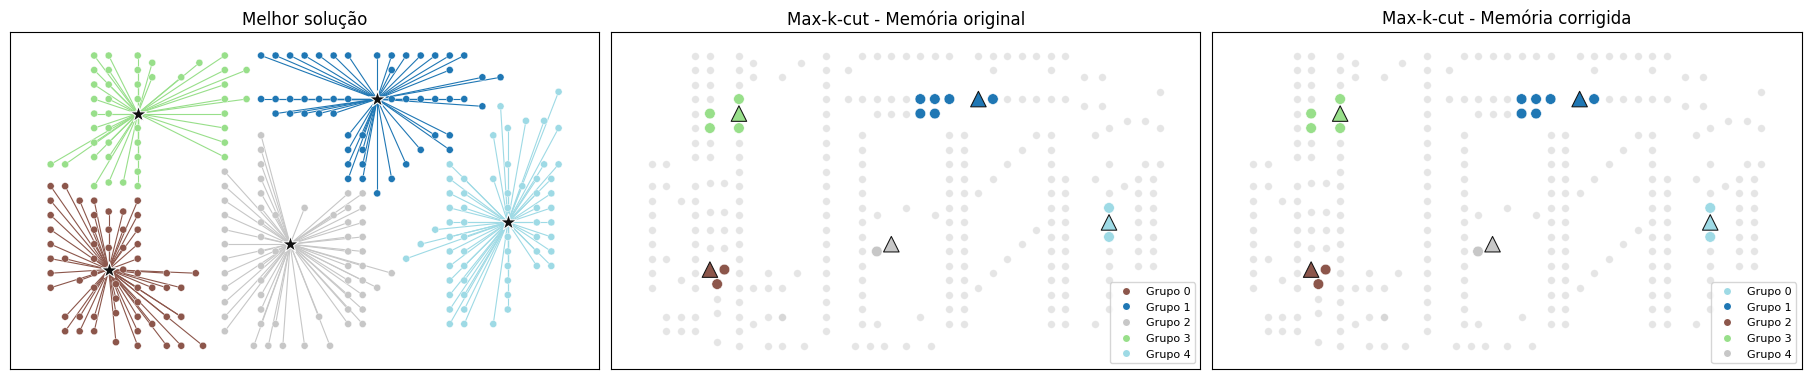

In [12]:
plot_three_column_comparison(RESULTS['a280'])

#### ali535

In [13]:
run_instance_tables('ali535')

Solving ali535 (n=535, p=5, type=GEO) ...


,memory,solution_count,swap_edges,component_count,largest_component_size,smallest_component_size,min_cost,median_cost,max_cost
0,original,104,459,1,104,104,958246.0,959743.0,960347.0
1,trajectory_corrected,104,459,1,104,104,958246.0,959743.0,960347.0


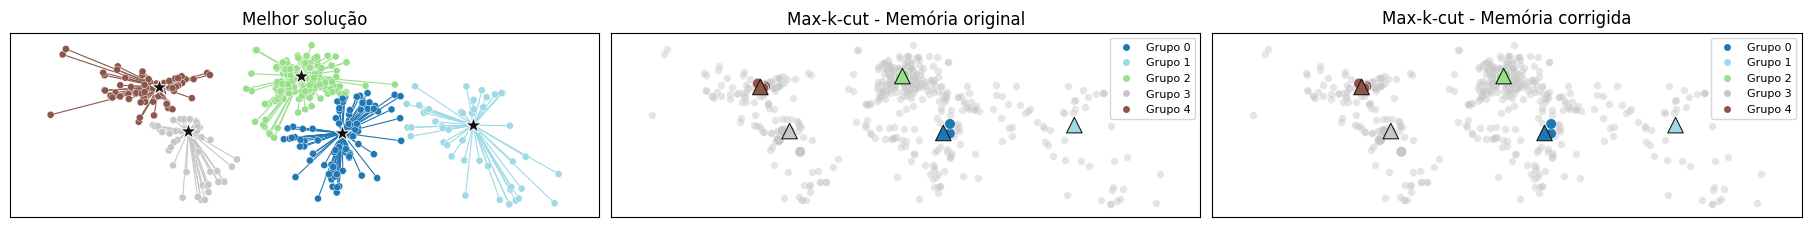

In [14]:
plot_three_column_comparison(RESULTS['ali535'])

#### att48

In [15]:
run_instance_tables('att48')

Solving att48 (n=48, p=5, type=ATT) ...


,memory,solution_count,swap_edges,component_count,largest_component_size,smallest_component_size,min_cost,median_cost,max_cost
0,original,8,10,1,8,8,12568.0,12716.5,12742.0
1,trajectory_corrected,8,10,1,8,8,12568.0,12716.5,12742.0


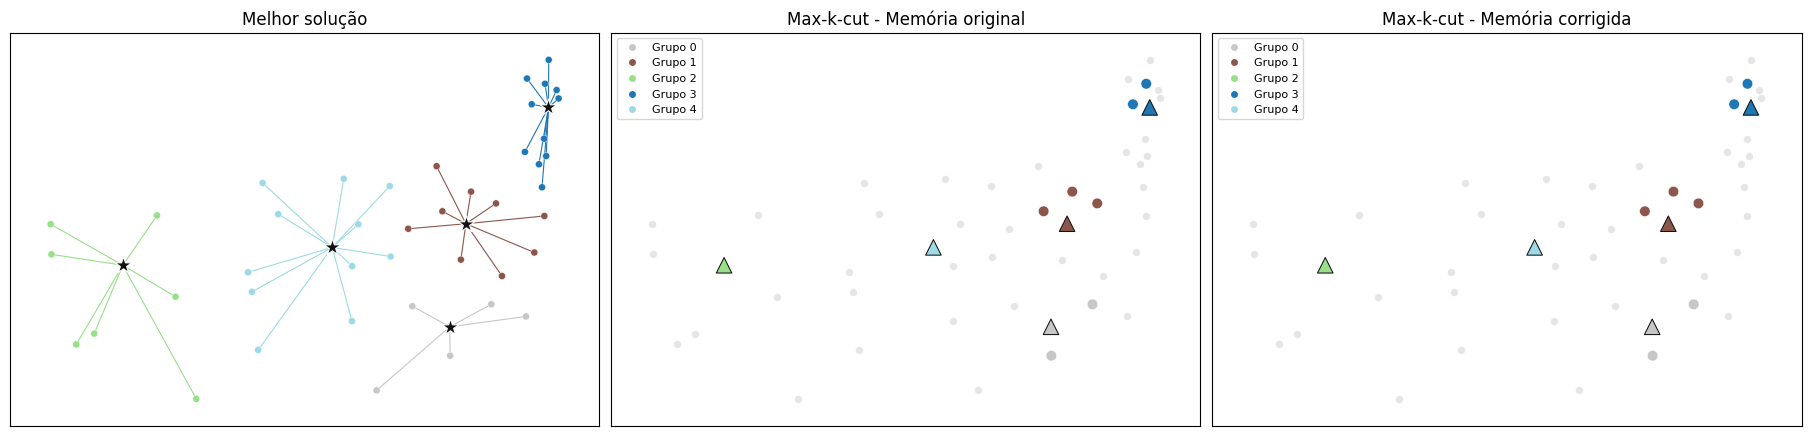

In [16]:
plot_three_column_comparison(RESULTS['att48'])

#### att 532

In [17]:
run_instance_tables('att532')

Solving att532 (n=532, p=5, type=ATT) ...


,memory,solution_count,swap_edges,component_count,largest_component_size,smallest_component_size,min_cost,median_cost,max_cost
0,original,86,383,1,86,86,142377.0,142668.0,142739.0
1,trajectory_corrected,86,383,1,86,86,142377.0,142668.0,142739.0


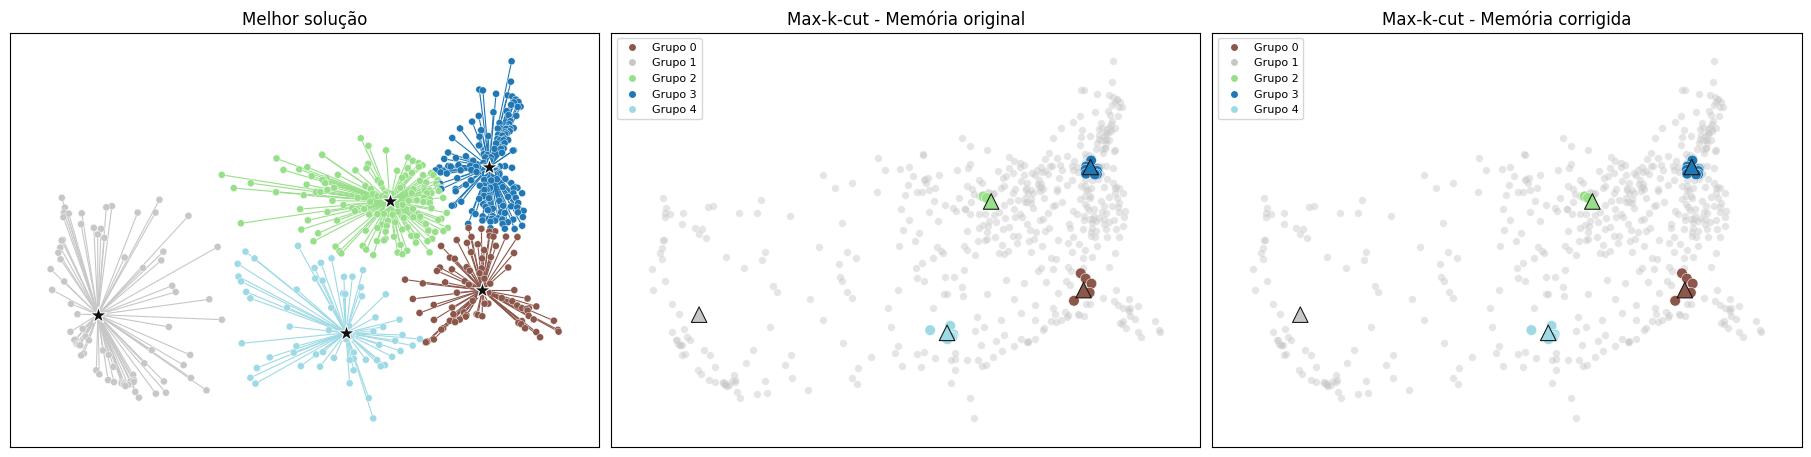

In [18]:
plot_three_column_comparison(RESULTS['att532'])

#### SUMMARY

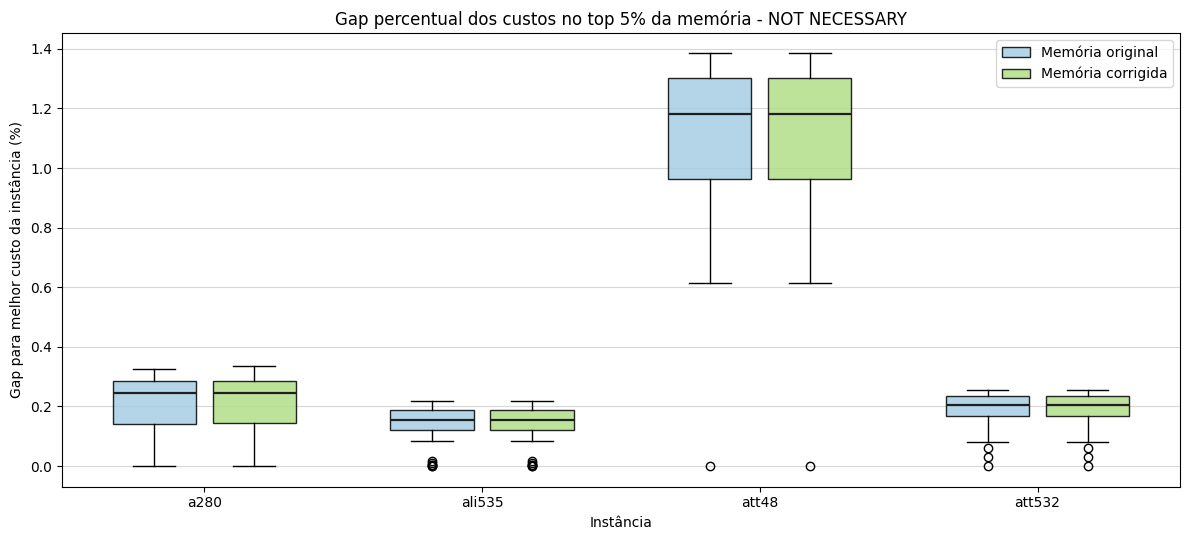

In [19]:
plot_group_cost_boxplot_pairs('NOT NECESSARY')

### WORKS

#### kroB200

In [20]:
run_instance_tables('kroB200')

Solving kroB200 (n=200, p=5, type=EUC_2D) ...


,memory,solution_count,swap_edges,component_count,largest_component_size,smallest_component_size,min_cost,median_cost,max_cost
0,original,40,98,2,38,2,97512.0,97953.5,98089.0
1,trajectory_corrected,41,101,1,41,41,97512.0,97958.0,98656.0


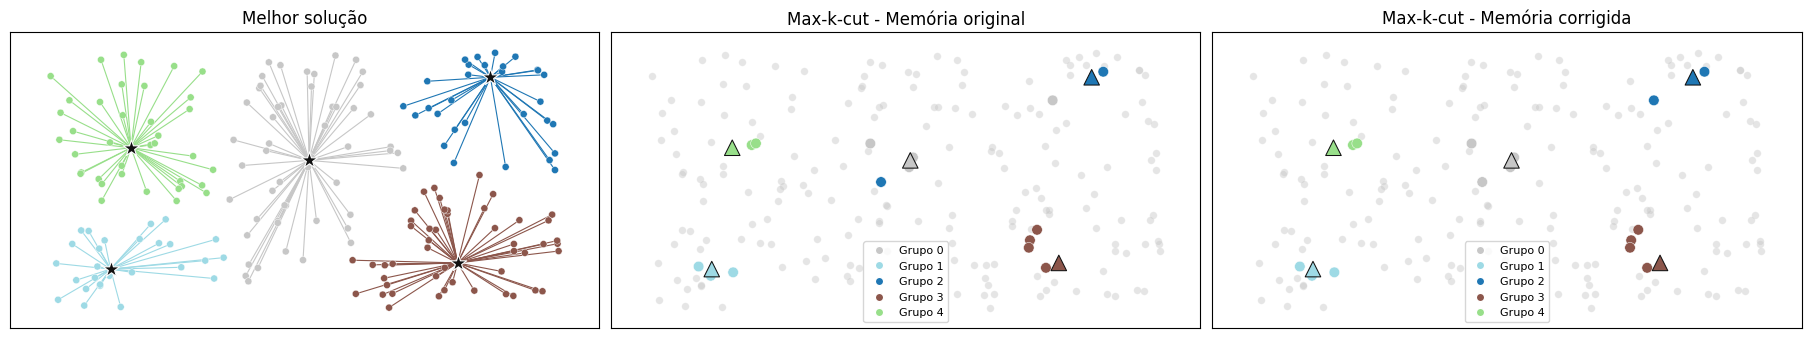

In [21]:
plot_three_column_comparison(RESULTS['kroB200'])

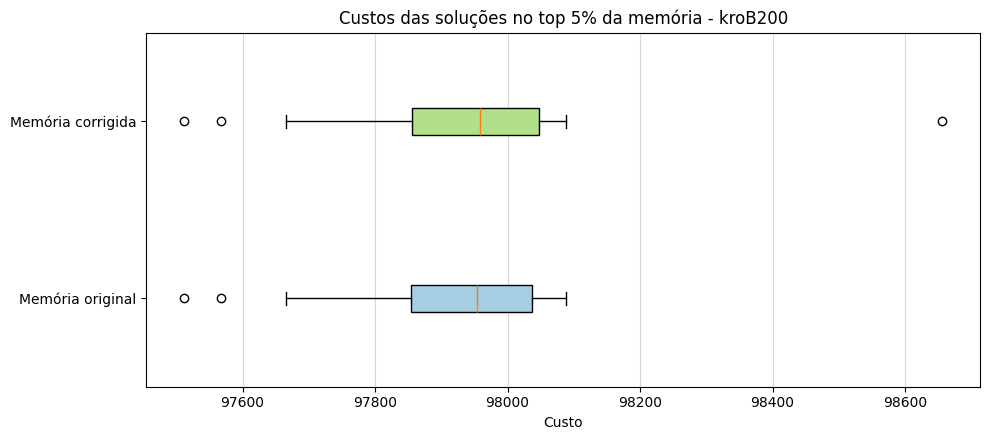

In [22]:
plot_cost_boxplots(RESULTS['kroB200'])

#### lin105

In [23]:
run_instance_tables('lin105')

Solving lin105 (n=105, p=5, type=EUC_2D) ...


,memory,solution_count,swap_edges,component_count,largest_component_size,smallest_component_size,min_cost,median_cost,max_cost
0,original,17,28,2,9,8,32395.0,32477.0,32537.0
1,trajectory_corrected,18,32,1,18,18,32395.0,32480.0,32712.0


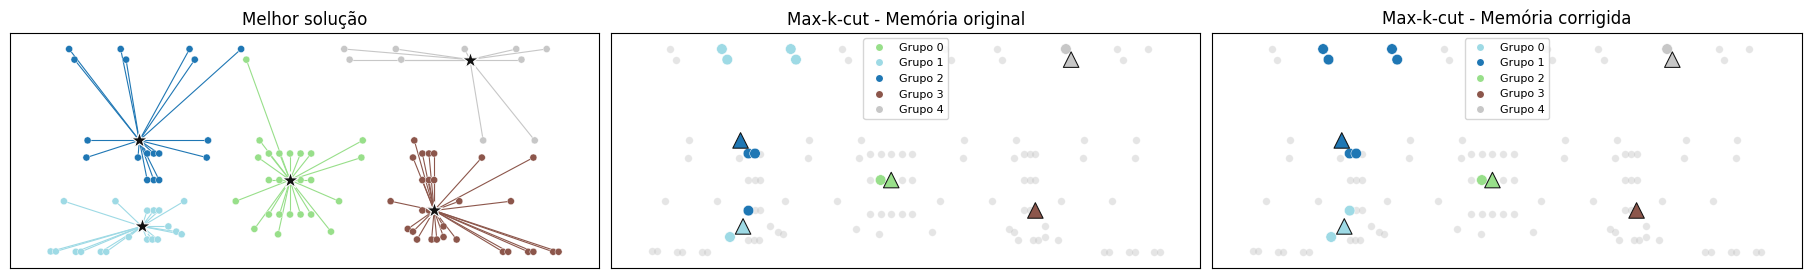

In [24]:
plot_three_column_comparison(RESULTS['lin105'])

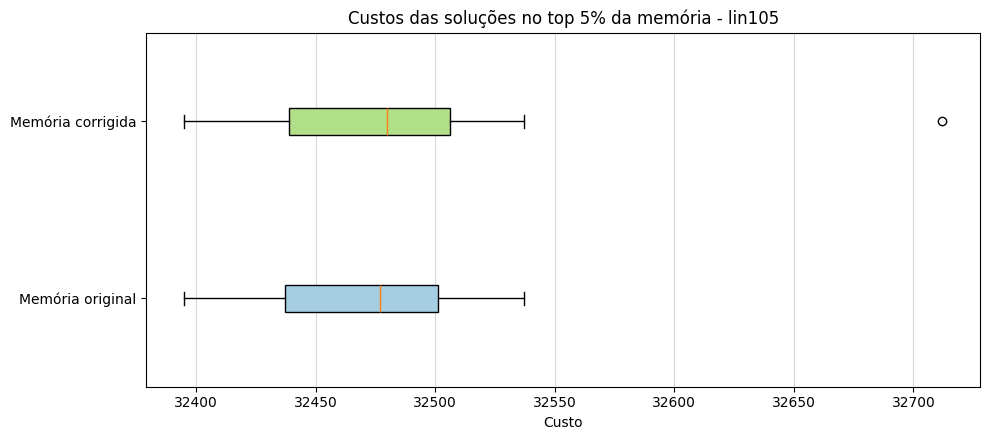

In [25]:
plot_cost_boxplots(RESULTS['lin105'])

#### rd100

In [26]:
run_instance_tables('rd100')

Solving rd100 (n=100, p=5, type=EUC_2D) ...


,memory,solution_count,swap_edges,component_count,largest_component_size,smallest_component_size,min_cost,median_cost,max_cost
0,original,16,28,2,15,1,16404.0,16428.5,16441.0
1,trajectory_corrected,18,31,1,18,18,16404.0,16429.5,16565.0


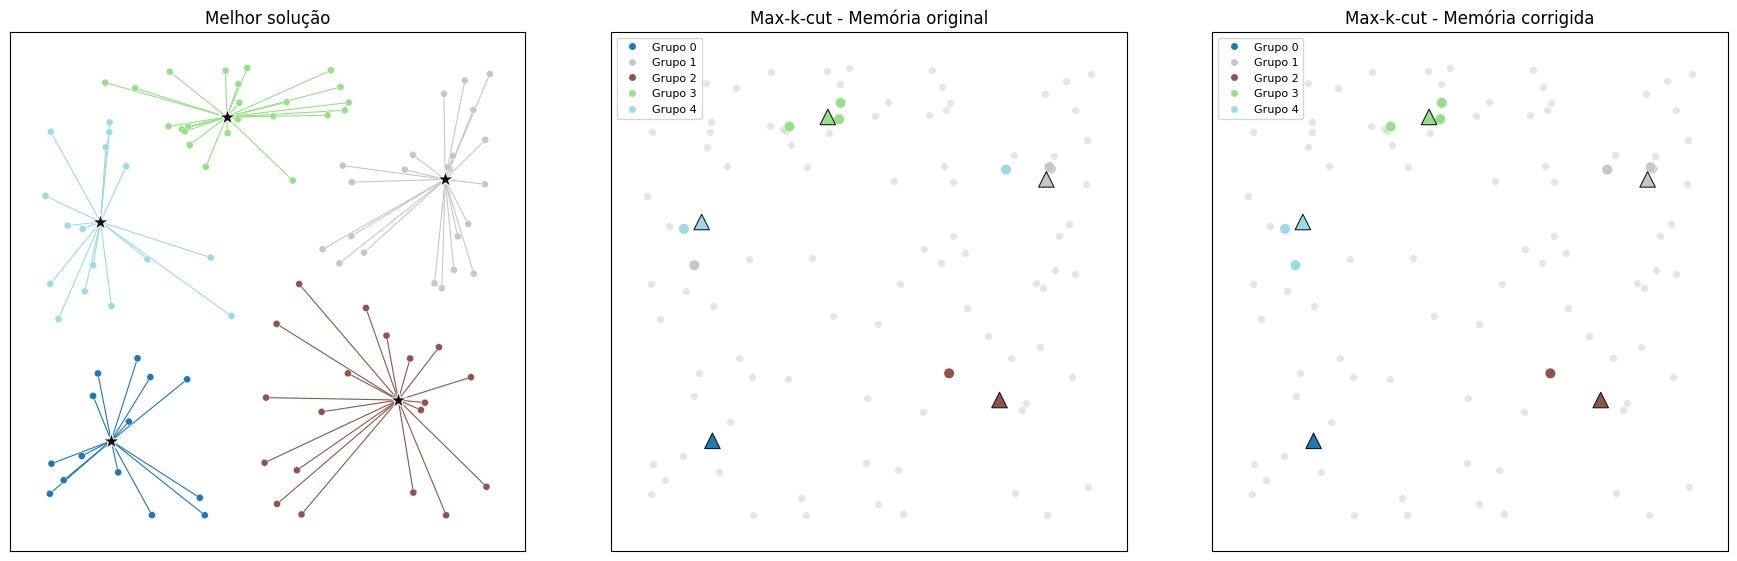

In [27]:
plot_three_column_comparison(RESULTS['rd100'])

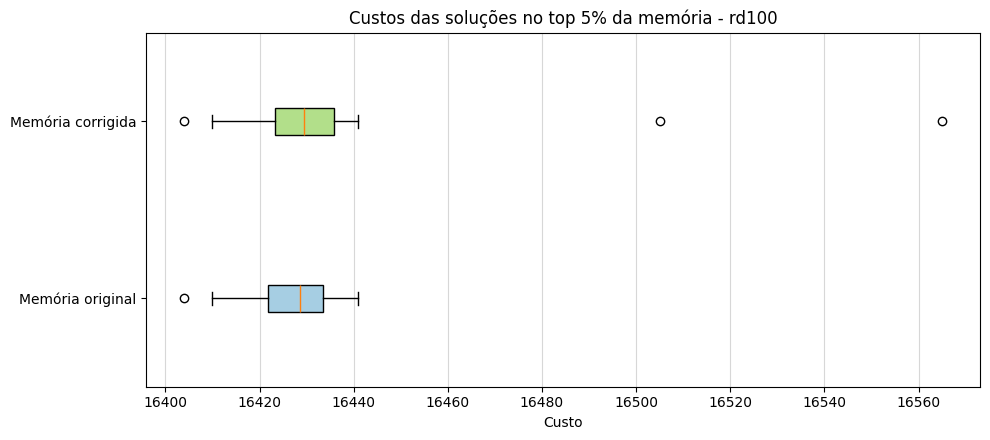

In [28]:
plot_cost_boxplots(RESULTS['rd100'])

#### u574

In [29]:
run_instance_tables('u574')

Solving u574 (n=574, p=5, type=EUC_2D) ...


,memory,solution_count,swap_edges,component_count,largest_component_size,smallest_component_size,min_cost,median_cost,max_cost
0,original,91,313,2,88,3,212074.0,212285.0,212341.0
1,trajectory_corrected,94,322,1,94,94,212074.0,212288.5,214285.0


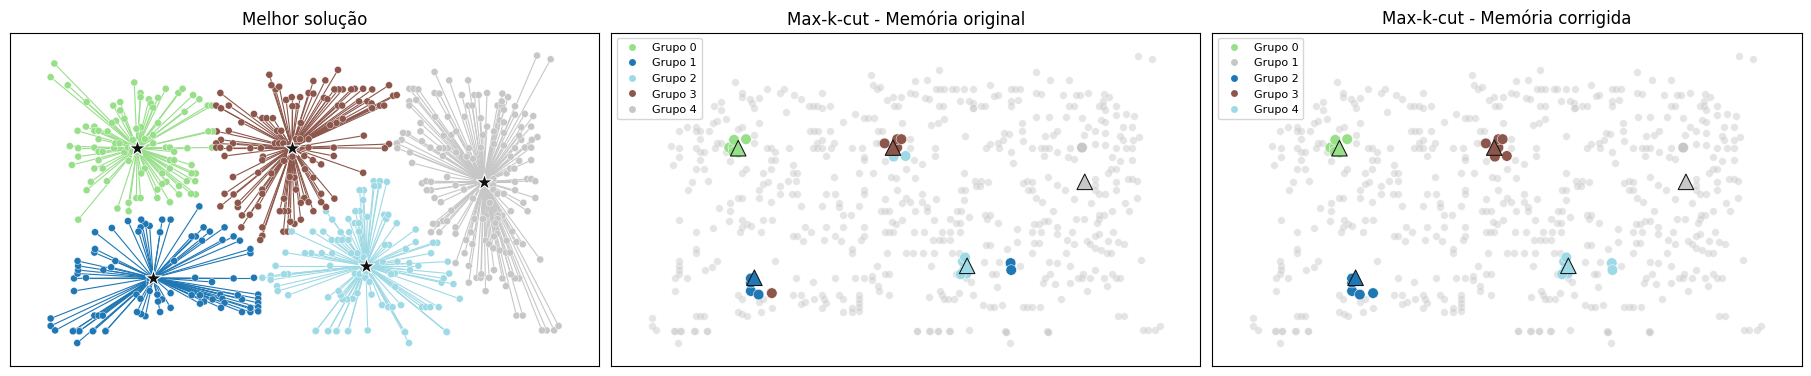

In [30]:
plot_three_column_comparison(RESULTS['u574'])

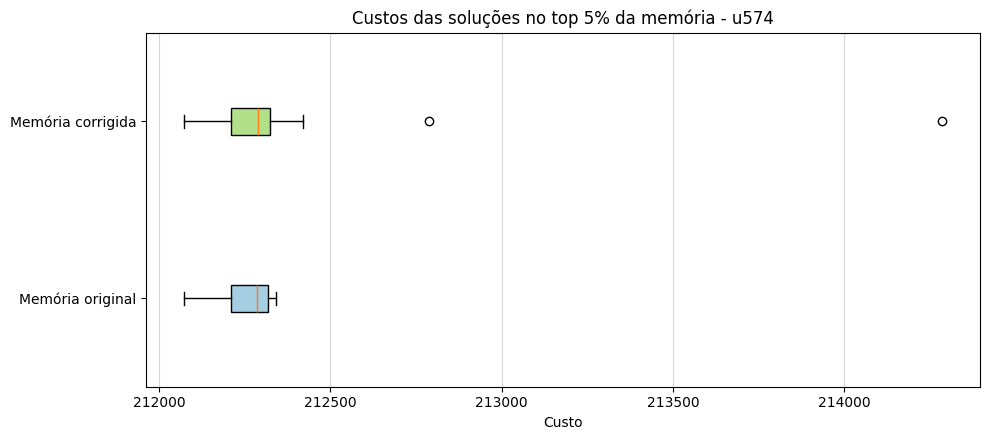

In [31]:
plot_cost_boxplots(RESULTS['u574'])

#### SUMMARY

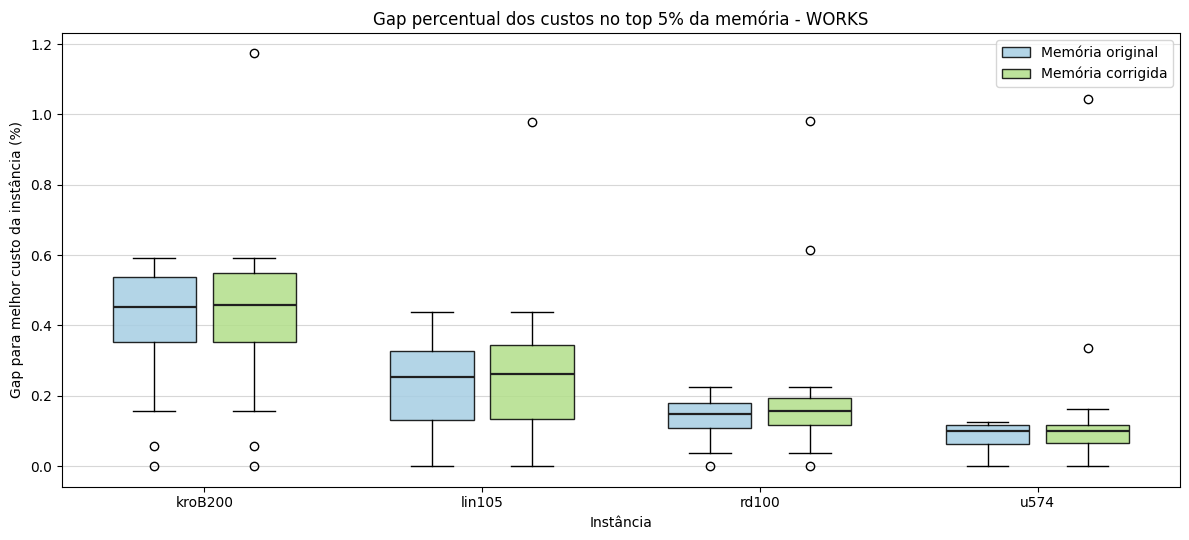

In [32]:
plot_group_cost_boxplot_pairs('WORKS')

### NOT WORKS

#### pr136

In [33]:
run_instance_tables('pr136')

Solving pr136 (n=136, p=5, type=EUC_2D) ...


,memory,solution_count,swap_edges,component_count,largest_component_size,smallest_component_size,min_cost,median_cost,max_cost
0,original,32,48,4,8,8,220692.0,220692.0,220692.0
1,trajectory_corrected,36,57,1,36,36,220692.0,220692.0,223879.0


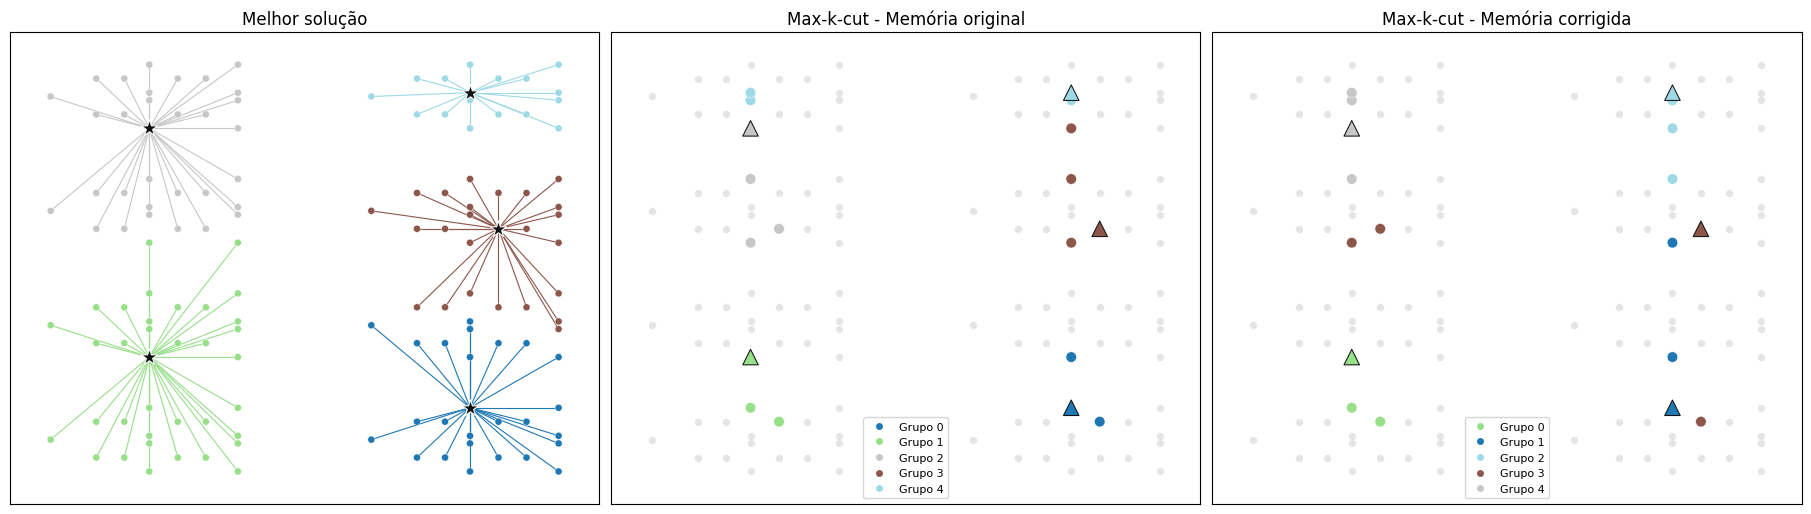

In [34]:
plot_three_column_comparison(RESULTS['pr136'])

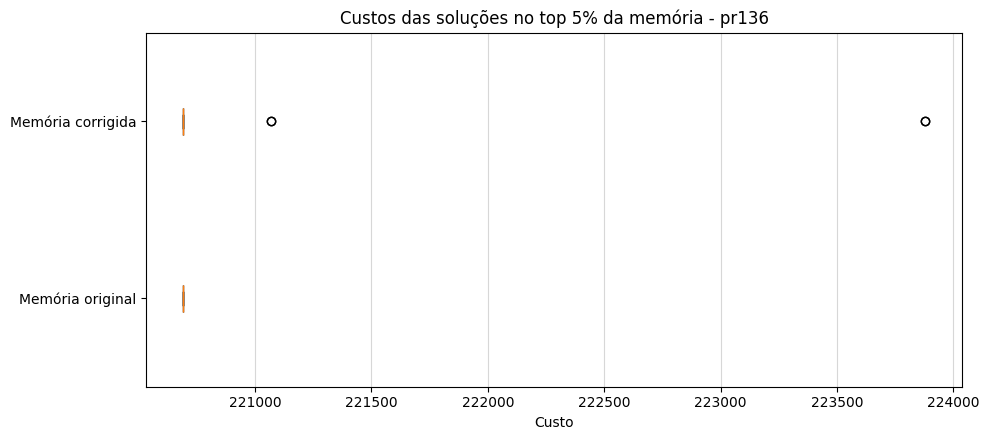

In [35]:
plot_cost_boxplots(RESULTS['pr136'])

#### rat195

In [36]:
run_instance_tables('rat195')

Solving rat195 (n=195, p=5, type=EUC_2D) ...


,memory,solution_count,swap_edges,component_count,largest_component_size,smallest_component_size,min_cost,median_cost,max_cost
0,original,42,56,5,19,1,6894.0,6913.0,6918.0
1,trajectory_corrected,49,72,1,49,49,6894.0,6913.0,7195.0


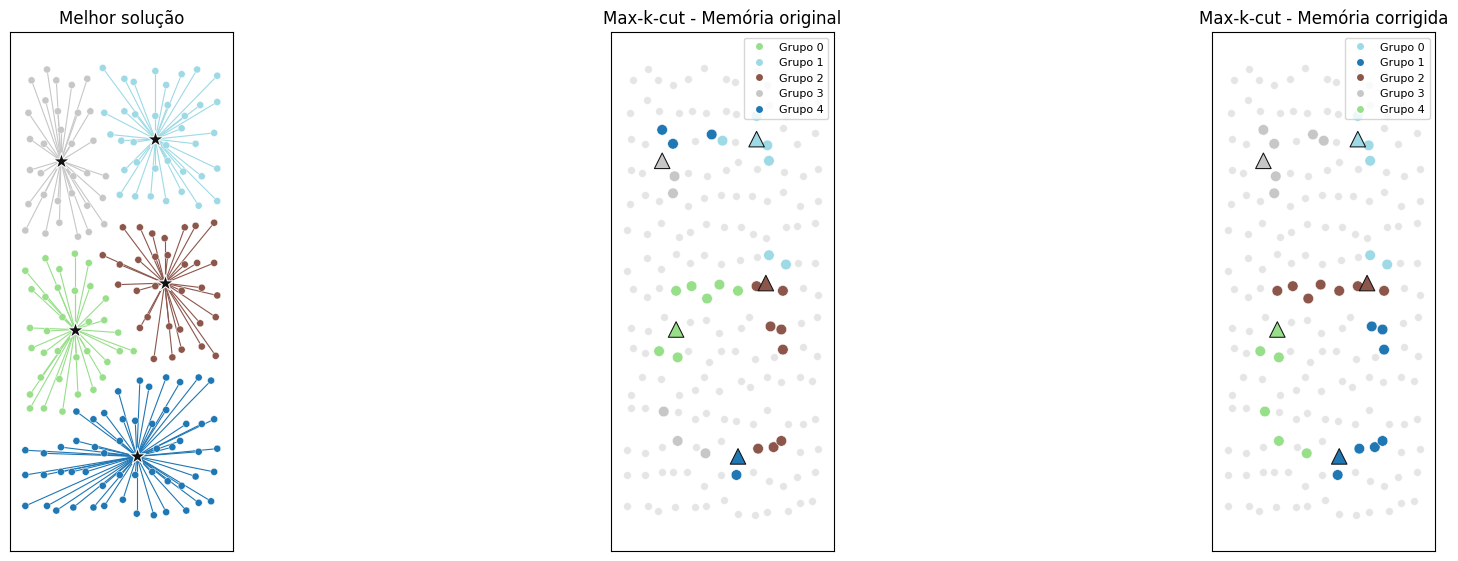

In [37]:
plot_three_column_comparison(RESULTS['rat195'])

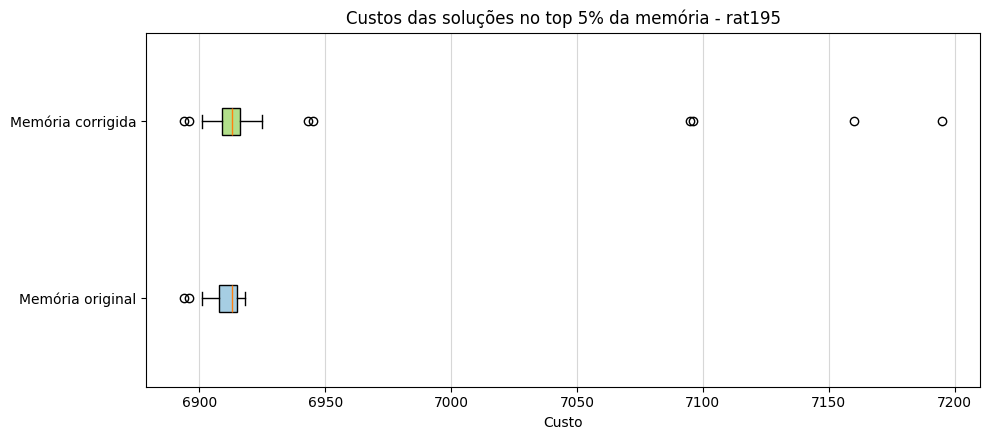

In [38]:
plot_cost_boxplots(RESULTS['rat195'])

#### bier127

In [39]:
run_instance_tables('bier127')

Solving bier127 (n=127, p=5, type=EUC_2D) ...


,memory,solution_count,swap_edges,component_count,largest_component_size,smallest_component_size,min_cost,median_cost,max_cost
0,original,23,41,2,19,4,233099.0,233662.0,233863.0
1,trajectory_corrected,25,45,1,25,25,233099.0,233669.0,237719.0


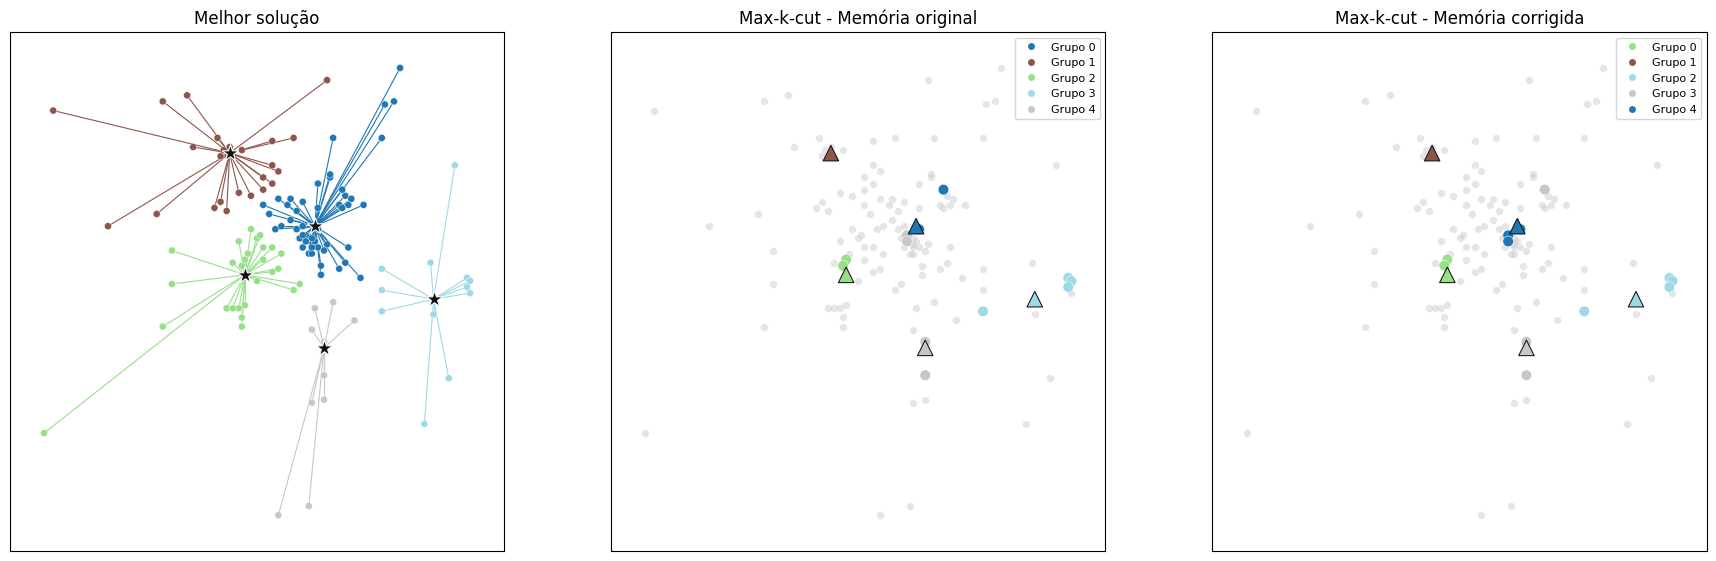

In [40]:
plot_three_column_comparison(RESULTS['bier127'])

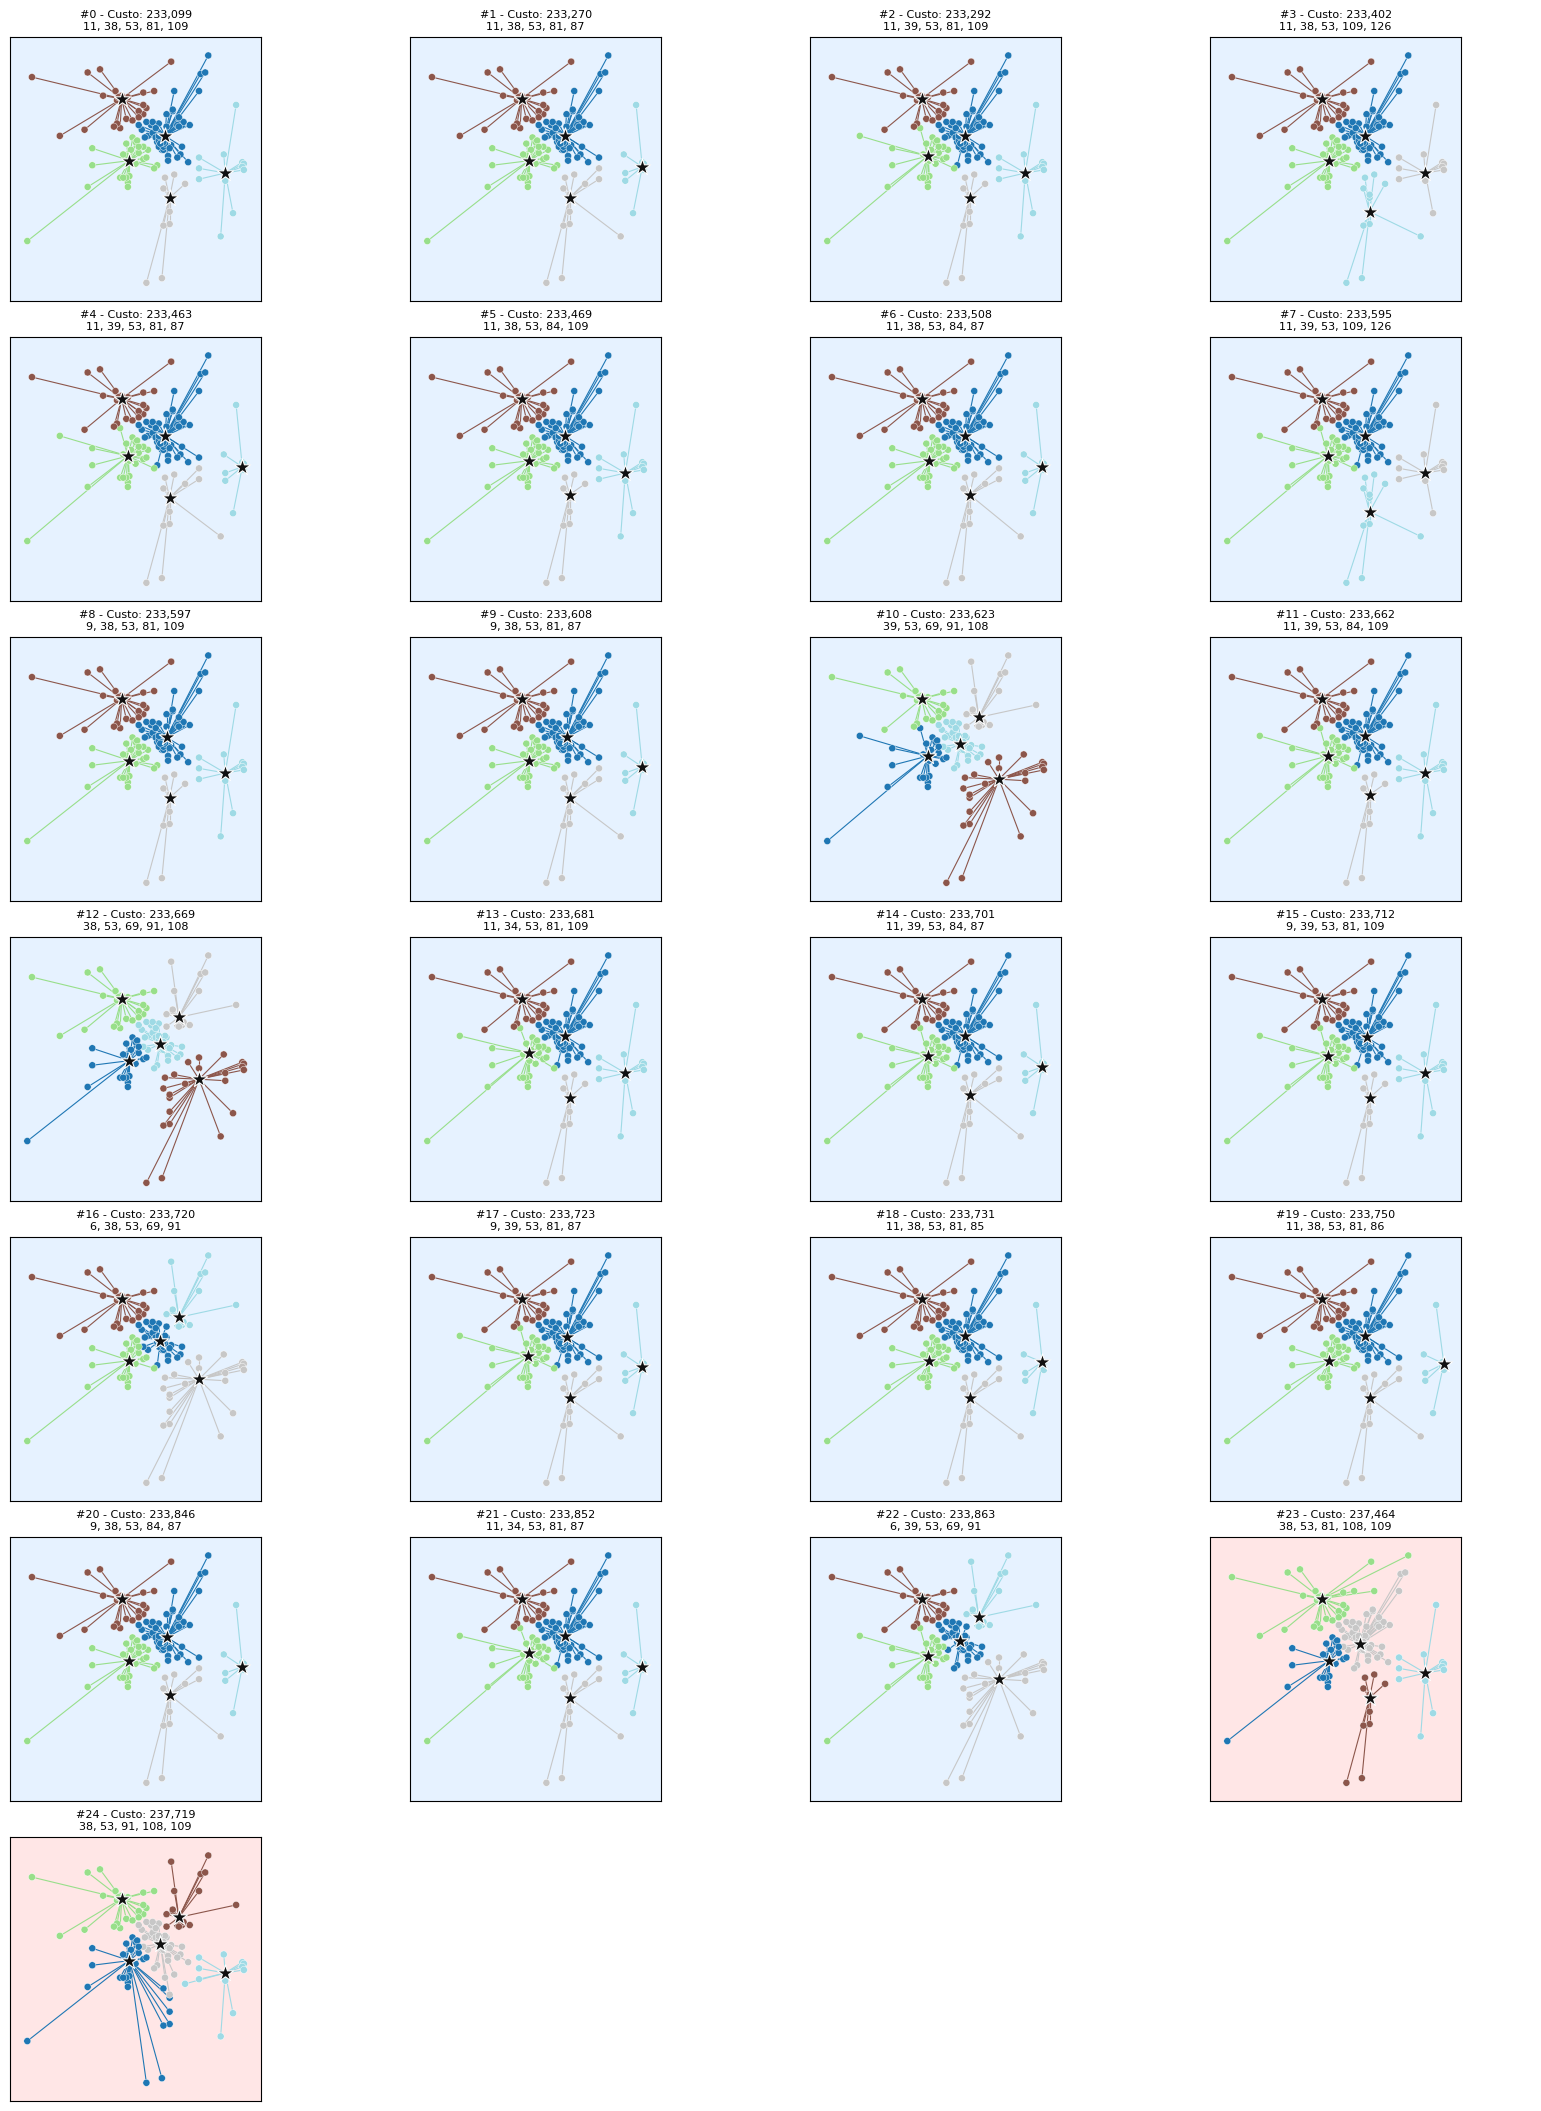

In [41]:
instance = 'bier127'

analysis = RESULTS [instance]
memory   = analysis['connected_memory' ]
origins  = analysis['swap_connectivity']['solution_origin']

n    = len(memory)
cols = 4
rows = ceil(n / cols)

fig, axes = plt.subplots(
    rows, cols, figsize=(cols * 4, rows * 3), constrained_layout=True
)

axes = axes.flatten()

show_map_background = SHOW_BASEMAPS and analysis['spec'].edge_weight_type == 'GEO'

for i, (record, origin) in enumerate(zip(memory, origins)):
    ax       = axes[i]
    is_added = origin != 'original'
    bgcolor  = '#ffe6e6' if is_added else '#e6f2ff'

    ax.set_facecolor(bgcolor)

    selected                = facilities_from_binary_vector(record['facilities'])
    _, assignments, _, _, _ = assignment_profile           (
        analysis['connected_result']['instance'], selected
    )

    temp_result = copy.copy(analysis['connected_result'])
    temp_result['selected'   ] = selected
    temp_result['assignments'] = assignments

    plot_solution_map(
        temp_result,
        ax                 =ax                 ,
        seed               =GLOBAL_SEED        ,
        show_map_background=show_map_background,
    )

    cost       = float(record['cost'])
    facilities = ', '.join(str(node + 1) for node in selected)

    ax.set_title(
        f'#{i} - Custo: {cost:,.0f}\n{facilities}',
        fontsize=8,
    )

for j in range(n, rows * cols):
    axes[j].axis('off')

plt.show()

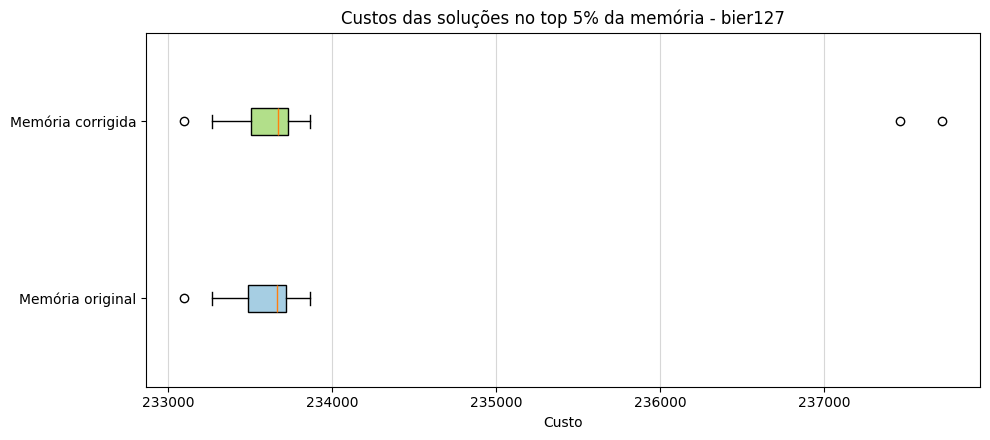

In [42]:
plot_cost_boxplots(RESULTS['bier127'])

#### pr226

In [43]:
run_instance_tables('pr226')

Solving pr226 (n=226, p=5, type=EUC_2D) ...


,memory,solution_count,swap_edges,component_count,largest_component_size,smallest_component_size,min_cost,median_cost,max_cost
0,original,42,101,2,30,12,396560.0,396953.0,397137.0
1,trajectory_corrected,44,107,1,44,44,396560.0,396957.5,407075.0


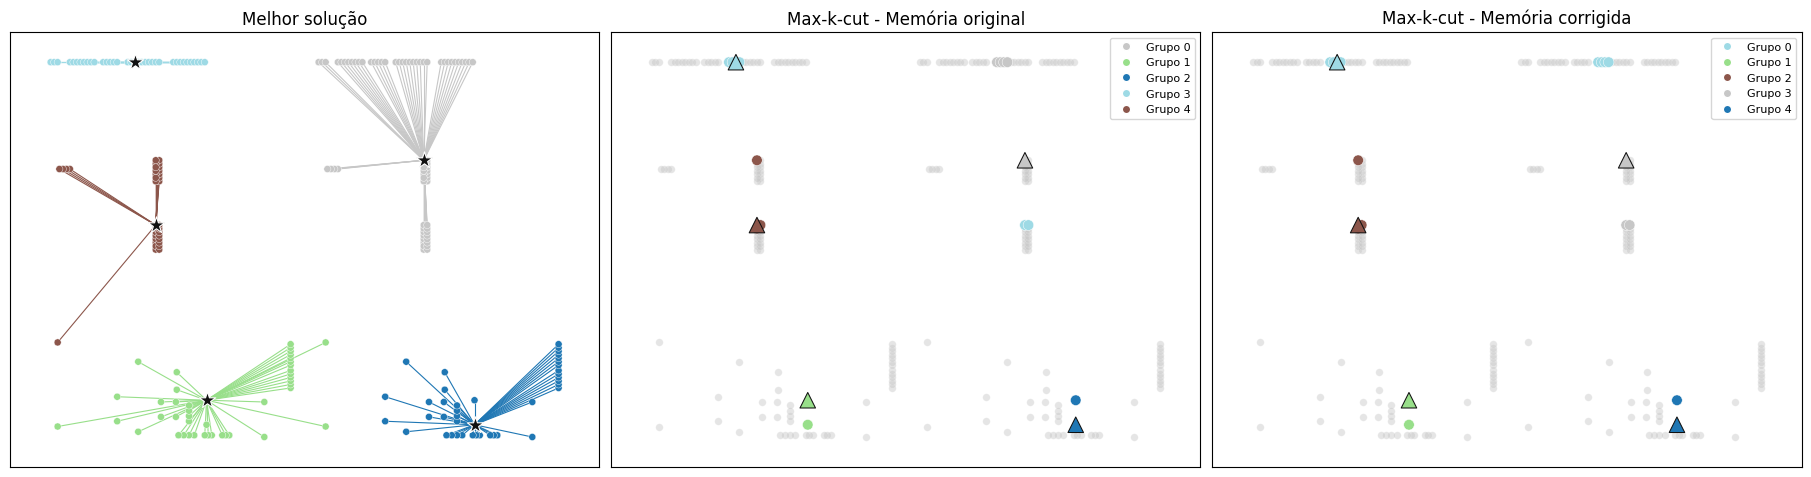

In [44]:
plot_three_column_comparison(RESULTS['pr226'])

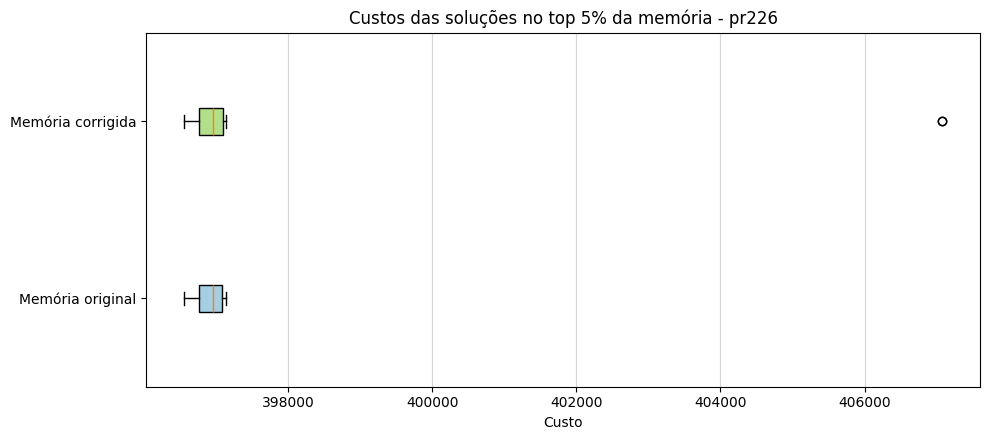

In [45]:
plot_cost_boxplots(RESULTS['pr226'])

#### SUMMARY

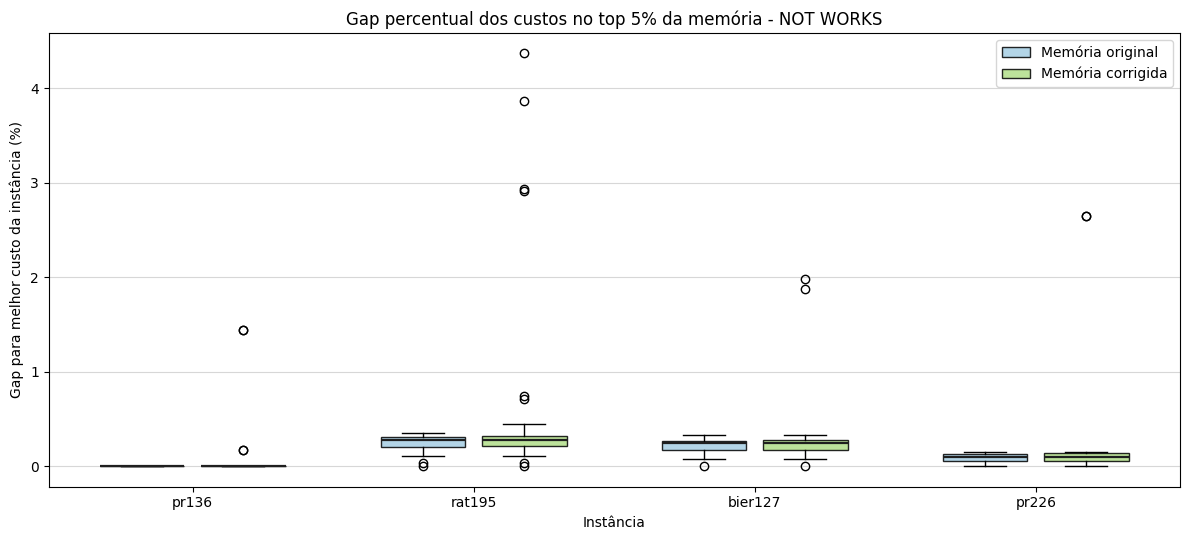

In [46]:
plot_group_cost_boxplot_pairs('NOT WORKS')

### AGGREGATED SUMMARY

In [47]:
expected_instances = [
    str(config['name'])
    for configs in INSTANCE_GROUPS.values()
    for config  in configs
]

summary_rows = []

for group_name, configs in INSTANCE_GROUPS.items():
    for config in configs:
        name              = str(config['name'])
        analysis          = RESULTS [name]
        swap_connectivity = analysis['swap_connectivity']

        summary_rows.append(
            {
                'group'    : group_name,
                'instance' : name      ,
                'n'        : analysis['spec'].dimension,
                'p'        : analysis['spec'].p        ,
                'cost'     : analysis['original_result']['summary']['tspmed_cost'],

                'original_solution_count' : swap_connectivity['original_solution_count' ],
                'added_solution_count'    : swap_connectivity['added_solution_count'    ],
                'original_components'     : swap_connectivity['original_component_count'],
            }
        )

display(pd.DataFrame(summary_rows))

,group,instance,n,p,cost,original_solution_count,added_solution_count,original_components
0,WORKS,kroB200,200,5,97512.0,40,1,2
1,WORKS,lin105,105,5,32395.0,17,1,2
2,WORKS,rd100,100,5,16404.0,16,2,2
3,WORKS,u574,574,5,212074.0,91,3,2
4,NOT WORKS,pr136,136,5,220692.0,32,4,4
5,NOT WORKS,rat195,195,5,6894.0,42,7,5
6,NOT WORKS,bier127,127,5,233099.0,23,2,2
7,NOT WORKS,pr226,226,5,396560.0,42,2,2
8,NOT NECESSARY,a280,280,5,10171.0,47,1,2
9,NOT NECESSARY,ali535,535,5,958246.0,104,0,1


In [48]:
group_names = ['WORKS', 'NOT WORKS']

outlier_summary = []
outlier_details = []

for group_name in group_names:
    for config in INSTANCE_GROUPS[group_name]:
        name     = str(config['name'])
        analysis = RESULTS [name]
        memory   = analysis['connected_memory']

        costs = pd.Series([float(record['cost']) for record in memory])

        q1, q3 = costs.quantile([0.25, 0.75])
        iqr    = q3 - q1
        lower  = q1 - 1.5 * iqr
        upper  = q3 + 1.5 * iqr

        origins         = analysis['swap_connectivity']['solution_origin']
        outlier_mask    = (costs < lower) | (costs > upper)
        outlier_indices = list(costs.index[outlier_mask])
        outlier_count   = len (outlier_indices          )

        outlier_summary.append({
            'group'    : group_name,
            'instance' : name      ,

            'connected_memory_size' : len(costs)   ,
            'outlier_count'         : outlier_count,
            'outlier_ratio'         : outlier_count / len(costs) if len(costs) else 0.0,
        })

        for idx in outlier_indices:
            record = memory [idx]
            origin = origins[idx] if idx < len(origins) else 'unknown'

            outlier_details.append({
                'group'    : group_name,
                'instance' : name      ,
                'index'    : idx       ,
                'cost'     : float(record['cost']),
                'origin'   : origin               ,

                'facilities'      : facilities_from_binary_vector(record['facilities']),
                'lower_bound'     : float(lower),
                'upper_bound'     : float(upper),
                'is_low_outlier'  : float(record['cost']) < lower,
                'is_high_outlier' : float(record['cost']) > upper,
            })


display(
    pd.DataFrame(outlier_summary)
    .sort_values(['group', 'instance'])
    .reset_index(drop=True)
)

,group,instance,connected_memory_size,outlier_count,outlier_ratio
0,NOT WORKS,bier127,25,3,0.120000
1,NOT WORKS,pr136,36,4,0.111111
2,NOT WORKS,pr226,44,2,0.045455
3,NOT WORKS,rat195,49,8,0.163265
4,WORKS,kroB200,41,3,0.073171
5,WORKS,lin105,18,1,0.055556
6,WORKS,rd100,18,3,0.166667
7,WORKS,u574,94,2,0.021277


In [49]:
if 'outlier_df' not in globals() and 'outlier_details' in globals():
    outlier_df = pd.DataFrame(outlier_details)

full_ltm_outlier_check = []
outside_rows           = []

for group_name in ['WORKS', 'NOT WORKS']:
    for config in INSTANCE_GROUPS[group_name]:
        name = str(config['name'])

        full_costs = pd.Series(
            [
                float(record['cost'])
                for record in RESULTS[name]['solved_result']['details']['long_term_memory']
            ]
        )
        full_min = float(full_costs.min())
        full_max = float(full_costs.max())

        instance_outliers = outlier_df[
            (outlier_df['group'   ] == group_name) &
            (outlier_df['instance'] == name      )
        ].copy()

        if not instance_outliers.empty:
            instance_outliers['within_full_range'] = instance_outliers['cost'].between(full_min, full_max, inclusive='both')

            outside_rows.append(
                instance_outliers[~instance_outliers['within_full_range']]
            )

        full_ltm_outlier_check.append({
            'group'    : group_name,
            'instance' : name      ,

            'full_min_cost' : full_min,
            'full_max_cost' : full_max,

            'outlier_count'            : len (  instance_outliers),
            'outside_full_range_count' : int ((~instance_outliers['within_full_range']).sum()) if not instance_outliers.empty else 0   ,
            'all_within_full_range'    : bool(  instance_outliers['within_full_range'] .all()) if not instance_outliers.empty else True,
        })

display(
    pd.DataFrame(full_ltm_outlier_check)
    .sort_values(['group', 'instance'])
    .reset_index(drop=True)
)

,group,instance,full_min_cost,full_max_cost,outlier_count,outside_full_range_count,all_within_full_range
0,NOT WORKS,bier127,233099.0,236268.0,3,2,False
1,NOT WORKS,pr136,220692.0,223592.0,4,2,False
2,NOT WORKS,pr226,396560.0,399281.0,2,2,False
3,NOT WORKS,rat195,6894.0,6997.0,8,4,False
4,WORKS,kroB200,97512.0,101803.0,3,0,True
5,WORKS,lin105,32395.0,33062.0,1,0,True
6,WORKS,rd100,16404.0,17054.0,3,0,True
7,WORKS,u574,212074.0,215463.0,2,0,True


In [50]:
if outside_rows:
    display(pd.concat(outside_rows, ignore_index=True))
else:
    print('Todos os outliers das instâncias WORKS e NOT WORKS estão dentro da faixa de custos da LTM completa.')

,group,instance,index,cost,origin,facilities,lower_bound,upper_bound,is_low_outlier,is_high_outlier,within_full_range
0,NOT WORKS,pr136,33,223879.0,trajectory,"(30, 32, 78, 103, 105)",220692.0,220692.0,False,True,False
1,NOT WORKS,pr136,34,223879.0,trajectory,"(30, 32, 74, 103, 105)",220692.0,220692.0,False,True,False
2,NOT WORKS,rat195,44,7160.0,trajectory,"(33, 81, 97, 159, 165)",6898.5,6926.5,False,True,False
3,NOT WORKS,rat195,45,7095.0,trajectory,"(29, 33, 97, 159, 165)",6898.5,6926.5,False,True,False
4,NOT WORKS,rat195,46,7096.0,trajectory,"(29, 36, 94, 159, 165)",6898.5,6926.5,False,True,False
5,NOT WORKS,rat195,47,7195.0,trajectory,"(29, 36, 94, 113, 159)",6898.5,6926.5,False,True,False
6,NOT WORKS,bier127,23,237464.0,trajectory,"(37, 52, 80, 107, 108)",233173.5,234065.5,False,True,False
7,NOT WORKS,bier127,24,237719.0,trajectory,"(37, 52, 90, 107, 108)",233173.5,234065.5,False,True,False
8,NOT WORKS,pr226,42,407075.0,trajectory,"(7, 48, 131, 149, 172)",396272.5,397588.5,False,True,False
9,NOT WORKS,pr226,43,407075.0,trajectory,"(7, 48, 131, 149, 208)",396272.5,397588.5,False,True,False


In [51]:
gap_rows = []

for group_name in ['WORKS', 'NOT WORKS']:
    for config in INSTANCE_GROUPS[group_name]:
        instance_name = str(config['name'])

        original_costs  = [float(record['cost']) for record in RESULTS[instance_name]['original_memory' ]]
        connected_costs = [float(record['cost']) for record in RESULTS[instance_name]['connected_memory']]

        original_max  = max(original_costs )
        connected_max = max(connected_costs)

        gap_percent = ((connected_max - original_max) / original_max) * 100

        gap_rows.append({
            'group'    : group_name   ,
            'instance' : instance_name,
            'original_max_cost'  : original_max ,
            'connected_max_cost' : connected_max,
            'gap_percent'        : gap_percent  ,
        })


gap_df = (
    pd.DataFrame(gap_rows)
    .sort_values(['group', 'instance'])
    .reset_index(drop=True)
)

display(gap_df)

,group,instance,original_max_cost,connected_max_cost,gap_percent
0,NOT WORKS,bier127,233863.0,237719.0,1.648829
1,NOT WORKS,pr136,220692.0,223879.0,1.444094
2,NOT WORKS,pr226,397137.0,407075.0,2.502411
3,NOT WORKS,rat195,6918.0,7195.0,4.004047
4,WORKS,kroB200,98089.0,98656.0,0.578046
5,WORKS,lin105,32537.0,32712.0,0.537849
6,WORKS,rd100,16441.0,16565.0,0.754212
7,WORKS,u574,212341.0,214285.0,0.915509


In [52]:
group_gap = gap_df.groupby('group')['gap_percent'].agg(['mean', 'min', 'max'])

display(group_gap)

,mean,min,max
group,,,
NOT WORKS,2.399845,1.444094,4.004047
WORKS,0.696404,0.537849,0.915509
